In [1]:
import numpy as np
from mpi4py import MPI

import dolfinx
import dolfinx.plot
import ufl
import basix.ufl
from dolfinx.fem.petsc import LinearProblem

from fenicsx_ii import assemble_scalar

from mesh import GenMesh3D

In [2]:
N = 4

comm = MPI.COMM_WORLD
_, _, graph_nodes, graph_cells, cells_edges, lm_index, boundary_indices = GenMesh3D(2*N)

ufl_int = ufl.Mesh(basix.ufl.element("Lagrange", "interval", 1, shape=(3,)))

graph_mesh = dolfinx.mesh.create_mesh(
    comm,
    e=ufl_int,
    cells=graph_cells,
    x=graph_nodes,
)

lm_mesh, lm_map = dolfinx.mesh.create_submesh(
    graph_mesh,
    graph_mesh.topology.dim - 1,
    lm_index
)[:2]


In [3]:
edge_meshes = []
edge_entity_maps = []
edge_vertex_maps = []
edge_facet_markers = []

marker_indices = np.insert(boundary_indices, 1, lm_index).astype(np.int32)
marker_values = np.array([2, 1, 2, 2], dtype=np.int32)

boundary_marker = 2
bifurc_marker = 1

global_facet_markers = dolfinx.mesh.meshtags(
    graph_mesh,
    0,
    marker_indices,
    marker_values,
)

parent_vertex_map = graph_mesh.topology.index_map(0)
num_vertices_parent = parent_vertex_map.size_local + parent_vertex_map.num_ghosts
parent_vertex_marker = np.full(num_vertices_parent, -1, dtype=np.int32)
parent_vertex_marker[global_facet_markers.indices] = global_facet_markers.values

num_cells_in_edge = len(cells_edges[0])
cells_array = np.arange(num_cells_in_edge, dtype=np.int32)
cell_indices = []
cell_indices.append(cells_array)
cell_indices.append(2*cells_array + num_cells_in_edge)
cell_indices.append(2*cells_array + 1 + num_cells_in_edge)

# Identify cell indices by matching vertex pairs in cells_edges to graph_cells
for i, edge_group in enumerate(cells_edges):

    edge_mesh, edge_map, vertex_map = dolfinx.mesh.create_submesh(
        graph_mesh,
        graph_mesh.topology.dim,
        cell_indices[i],
    )[:3]

    edge_meshes.append(edge_mesh)
    edge_entity_maps.append(edge_map)
    edge_vertex_maps.append(vertex_map)

    num_submesh_vertices = (
        edge_mesh.topology.index_map(0).size_local +
        edge_mesh.topology.index_map(0).num_ghosts
    )
    parent_vertices = vertex_map.sub_topology_to_topology(
        np.arange(num_submesh_vertices, dtype=np.int32), inverse=False
    )
    sub_topology_values = parent_vertex_marker[parent_vertices]
    marked_vertices = np.flatnonzero(sub_topology_values >= 0)
    marked_values = sub_topology_values[marked_vertices].copy()

    edge_facet_markers.append(
        dolfinx.mesh.meshtags(edge_mesh, 0, marked_vertices.astype(np.int32), marked_values.astype(np.int32))
    )

/tmp/ipykernel_50316/497245233.py:17: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


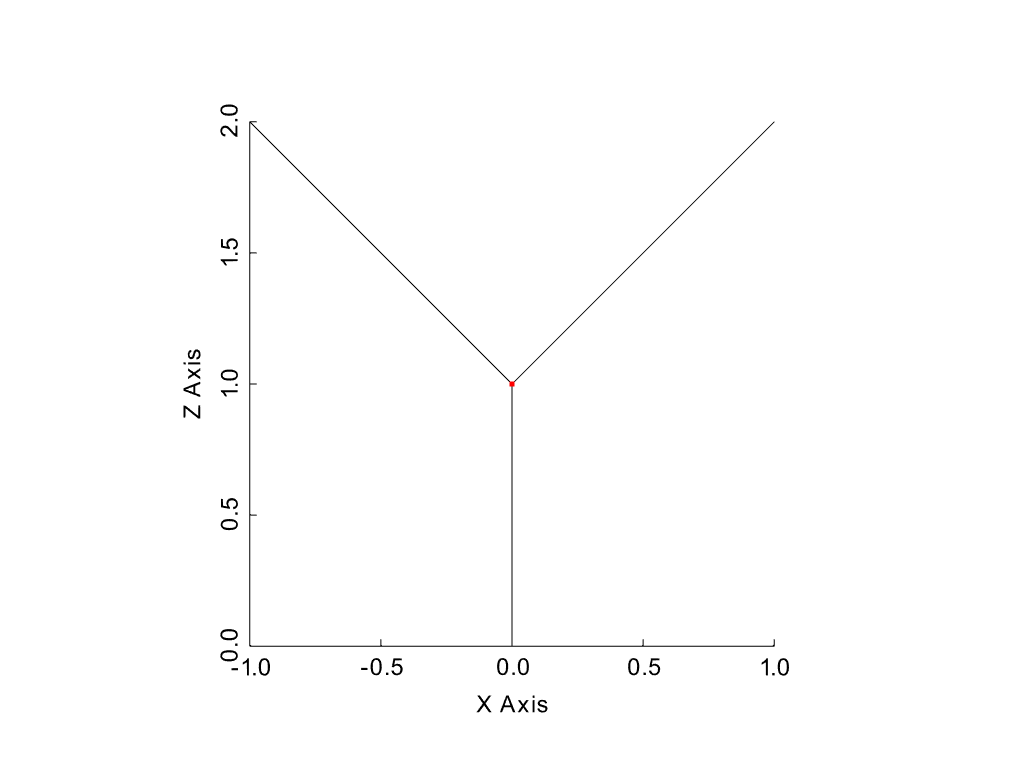

In [4]:
import pyvista as pv

plotter = pv.Plotter()

for edge_mesh in edge_meshes:
    topology, cell_types, geometry = dolfinx.plot.vtk_mesh(edge_mesh)
    grid1 = pv.UnstructuredGrid(topology, cell_types, geometry)
    plotter.add_mesh(grid1, show_edges=True, color="black")

topology_lm, cell_types_lm, geometry_lm = dolfinx.plot.vtk_mesh(lm_mesh)
grid_lm = pv.UnstructuredGrid(topology_lm, cell_types_lm, geometry_lm)
plotter.add_mesh(grid_lm, show_edges=True, color="red")

plotter.view_xz()
plotter.show_bounds()
plotter.screenshot("Y-mesh.png")
plotter.show()

In [5]:
# Create Function Spaces

degree = 1

edge_element = basix.ufl.element(
    family="DG",
    cell="interval",
    degree=degree,
    lagrange_variant=basix.LagrangeVariant.equispaced,
    discontinuous=True,
)

edge_spaces = [dolfinx.fem.functionspace(edge_mesh, edge_element) for edge_mesh in edge_meshes]

lm_space = dolfinx.fem.functionspace(lm_mesh, ("DG", 0))

function_spaces = [*edge_spaces, lm_space]


In [6]:
# Define Exact Solution

x = ufl.SpatialCoordinate(graph_mesh)

uhat_1 = x[2] + ufl.cos(2 * ufl.pi * x[2])
uhat_2 = 2 + 0.5 * ufl.sqrt(2) * (x[2] - 1)
u_ex = ufl.conditional(x[2] < 1, uhat_1, uhat_2)

# Global Function Space

fs_global = dolfinx.fem.functionspace(graph_mesh, ("DG", 1))
u_bc = dolfinx.fem.Function(fs_global)
bc_expr = dolfinx.fem.Expression(u_ex, fs_global.element.interpolation_points)
u_bc.interpolate(bc_expr)

# RHS function

f_edges = [
    4 * (ufl.pi ** 2) * ufl.cos(2 * ufl.pi * x[2]),
    0,
    0,
]

# u_bc on edges
u_bc_edges = []
for edge in edge_spaces:
  u_bc_edges.append(dolfinx.fem.Function(edge))
  bc_expr = dolfinx.fem.Expression(u_ex, edge.element.interpolation_points)
  u_bc_edges[-1].interpolate(bc_expr)


In [7]:
lm_to_edge_maps = []
lm_indices = np.array([0], dtype=np.int32)

for i, vertex_map in enumerate(edge_vertex_maps):
  lm_graph_indices = lm_map.sub_topology_to_topology(lm_indices, inverse=False)
  lm_to_edge = edge_vertex_maps[i].sub_topology_to_topology(lm_graph_indices, inverse=True)
  cpp_map = dolfinx.cpp.mesh.EntityMap(
      edge_meshes[i].topology._cpp_object,
      lm_mesh.topology._cpp_object,
      0,
      lm_to_edge,
  )
  lm_to_edge_maps.append(dolfinx.mesh.EntityMap(cpp_map))

In [8]:
# Initialize Forms
trial_functions_ = [ufl.TrialFunction(fs) for fs in function_spaces]
test_functions_ = [ufl.TestFunction(fs) for fs in function_spaces]

a = [
    [ufl.ZeroBaseForm((ui, vj)) for vj in test_functions_] for ui in trial_functions_
]
L = [
    ufl.ZeroBaseForm((ui,)) for ui in test_functions_
]

u_e, w_e = [], []
for edge in edge_spaces:
    u_e.append(ufl.TrialFunction(edge))
    w_e.append(ufl.TestFunction(edge))

u_tilde = ufl.TrialFunction(lm_space)
w_tilde = ufl.TestFunction(lm_space)

# DG Bilinear Form parameters
sigma_edges = 30
sigma_bifurc = 30

dS_global = ufl.Measure("dS", domain=graph_mesh, subdomain_data=global_facet_markers)

# Redefine forms to ensure they are properly categorized
for i, (edge, facet_marker) in enumerate(zip(edge_meshes, edge_facet_markers)):
    dx_edge = ufl.Measure("dx", domain=edge)
    dS_edge = ufl.Measure("dS", domain=edge)
    ds_edge = ufl.Measure("ds", domain=edge, subdomain_data=facet_marker)

    h_e = ufl.CellDiameter(edge)
    h_e_avg = (h_e("+") + h_e("-"))/2
    n_e = ufl.FacetNormal(edge)

    # DG Form - Diagonal blocks
    a[i][i] += ufl.inner(ufl.grad(u_e[i]), ufl.grad(w_e[i])) * dx_edge
    a[i][i] -= ufl.inner(ufl.avg(ufl.grad(u_e[i])), ufl.jump(w_e[i], n_e)) * dS_edge
    a[i][i] -= ufl.inner(ufl.avg(ufl.grad(w_e[i])), ufl.jump(u_e[i], n_e)) * dS_edge
    a[i][i] += (sigma_edges / h_e_avg) * ufl.inner(ufl.jump(u_e[i], n_e), ufl.jump(w_e[i], n_e)) * dS_edge

    # Boundary conditions
    a[i][i] -= ufl.inner(ufl.grad(u_e[i]), ufl.outer(w_e[i], n_e)) * ds_edge
    a[i][i] -= ufl.inner(ufl.grad(w_e[i]), ufl.outer(u_e[i], n_e)) * ds_edge
    a[i][i] += (sigma_edges / h_e) * ufl.inner(u_e[i], w_e[i]) * ds_edge

    # RHS Form
    L[i] += ufl.inner(w_e[i], f_edges[i]) * dx_edge
    L[i] += ufl.inner(ufl.grad(w_e[i]), ufl.outer(u_bc_edges[i], n_e)) * ds_edge(boundary_marker)
    L[i] += (sigma_edges / h_e) * ufl.inner(w_e[i], u_bc_edges[i]) * ds_edge(boundary_marker)

    # Bifurcation node coupling
    a[-1][i] += ufl.inner(ufl.grad(u_e[i]), ufl.outer(w_tilde, n_e)) * ds_edge(bifurc_marker)
    a[i][-1] += ufl.inner(ufl.grad(w_e[i]), ufl.outer(u_tilde, n_e)) * ds_edge(bifurc_marker)
    a[-1][i] += (sigma_bifurc / h_e) * ufl.inner(u_e[i], w_tilde) * ds_edge(bifurc_marker)
    a[i][-1] += (sigma_bifurc / h_e) * ufl.inner(w_e[i], u_tilde) * ds_edge(bifurc_marker)

entity_maps = edge_entity_maps + [lm_map] + lm_to_edge_maps

for i, ai in enumerate(a):
  for j, aij in enumerate(ai):
    if isinstance(aij, ufl.ZeroBaseForm):
      a[i][j] = None

L_form = dolfinx.fem.form(L, entity_maps=entity_maps)
a_form = dolfinx.fem.form(a, entity_maps=entity_maps)

In [33]:
from petsc4py import PETSc
import dolfinx

# Create and assemble the block matrix using standard dolfinx API
A_mat = dolfinx.fem.petsc.create_matrix(a_form)
A_mat.zeroEntries()
dolfinx.fem.petsc.assemble_matrix(A_mat, a_form, bcs=[])
A_mat.assemble()

# Extract function spaces and create the block RHS vector
spaces = dolfinx.fem.extract_function_spaces(L_form)
kind = "nest" if A_mat.getType() == "nest" else None

b_vec = dolfinx.fem.petsc.create_vector(spaces, kind=kind)
with b_vec.localForm() as loc_b:
    loc_b.set(0)
dolfinx.fem.petsc.assemble_vector(b_vec, L_form)
#b_vec.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)

# Create block solution vector
x = dolfinx.fem.petsc.create_vector(spaces, kind=kind)

# Configure and run the PETSc solver directly
ksp = PETSc.KSP().create(comm=comm)
ksp.setOperators(A_mat)
ksp.setType("preonly")
pc = ksp.getPC()
pc.setType("lu")
pc.setFactorSolverType("mumps")

ksp.solve(b_vec, x)

In [34]:
functions = []
for i, edge in enumerate(edge_spaces):
  functions.append(dolfinx.fem.Function(edge, name=f"edge_{i}"))
functions.append(dolfinx.fem.Function(lm_space, name="lm_value"))

dolfinx.la.petsc._ghost_update(
    x,
    insert_mode=PETSc.InsertMode.INSERT,
    scatter_mode=PETSc.ScatterMode.FORWARD,
)

dolfinx.fem.petsc.assign(x, functions)

In [35]:
def L22(f: ufl.core.expr.Expr, dx: ufl.Measure):
  integral = ufl.inner(f, f) * dx
  return assemble_scalar(integral, op=MPI.SUM)

sum = 0
for i, edge in enumerate(edge_meshes):
  dx_edge = ufl.Measure("dx", domain=edge)
  sum += L22(functions[i] - u_bc_edges[i], dx_edge)

print(np.sqrt(sum))


46.94189517434584


/tmp/ipykernel_34769/508707886.py:15: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


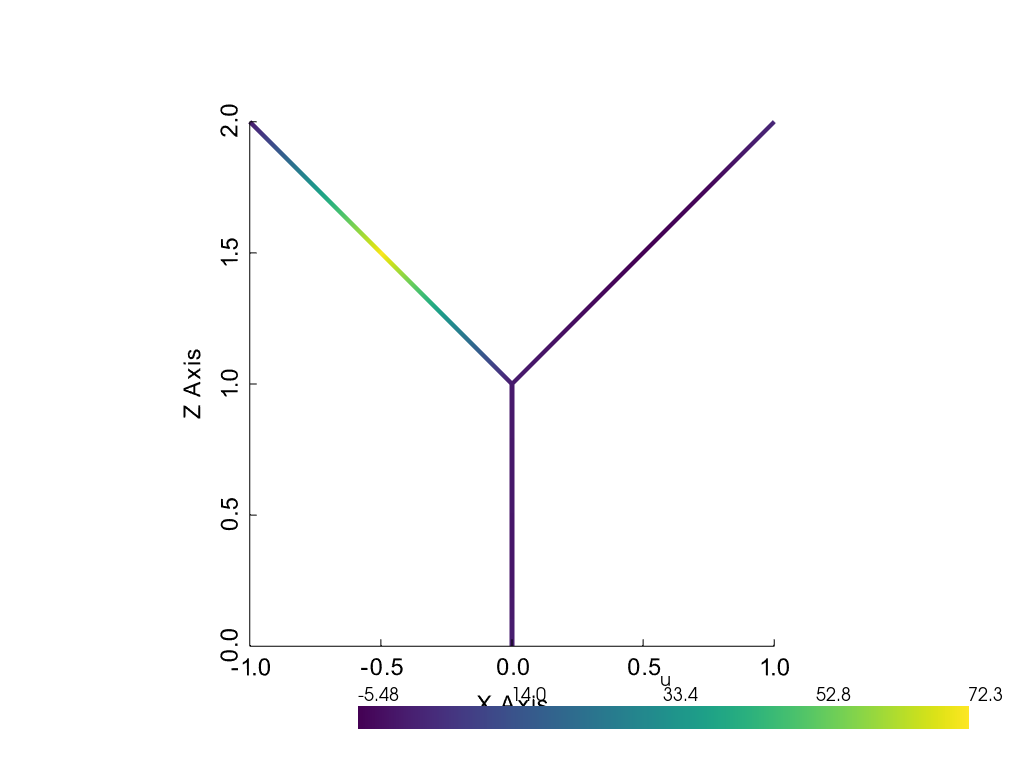

In [36]:
import pyvista as pv

plotter = pv.Plotter()

# Visualize the solution on each edge
for i, func in enumerate(functions[:-1]):  # Exclude the Lagrange multiplier
    topology, cell_types, geometry = dolfinx.plot.vtk_mesh(func.function_space)
    grid = pv.UnstructuredGrid(topology, cell_types, geometry)
    grid.point_data["u"] = func.x.array.real
    grid.set_active_scalars("u")
    plotter.add_mesh(grid, line_width=5, show_scalar_bar=True, cmap="viridis")

plotter.view_xz()
plotter.show_bounds()
plotter.show()